In [1]:
from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt

# PART 1

## Homoschedastic

### Generating Gaussian Data

In [2]:
mu=1
sigma=0.2
N=50
np.random.seed(3)
data=norm.rvs(mu, sigma, size=N)
mean=np.mean(data)

### Gaussian Likelihood

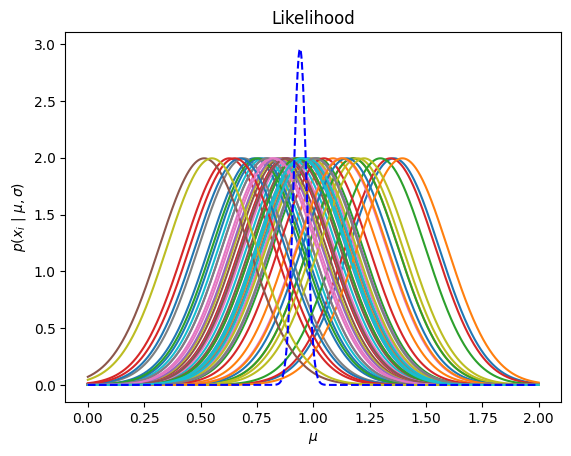

In [3]:
x=np.linspace(0,2,1000)
g=1
for i in range(N):
    dist=norm(data[i],sigma)
    y=dist.pdf(x)
    plt.plot(x,y)
    g=g*y
plt.plot(x,g/5000, linestyle="--", c='b')
plt.xlabel(r'$\mu$')
plt.ylabel(r'$p(x_i \ | \ \mu, \sigma)$')
plt.title("Likelihood");

In [4]:
idx=np.argmax(g)
maxL=x[idx]
print("Maximum Likelihood Estimator:",mean,"and value at which the Likelihood is maximized",maxL)
sigma_MLE=np.std(data)/np.sqrt(N)

Maximum Likelihood Estimator: 0.9412146359841184 and value at which the Likelihood is maximized 0.9409409409409409


# PART 2

### Fisher Matrix

In [6]:
logg=np.log(g)
g2=np.diff(logg,2)
g3=-g2/(x[1]-[0])**2
g2=1/np.sqrt(g3)[idx]
print("Fisher matrix error:", g2, "and error on the Maximum Likelihood Estimator:",sigma_MLE)

Fisher matrix error: 0.028284271247442663 and error on the Maximum Likelihood Estimator: 0.028240862781550743


### Likelihood check

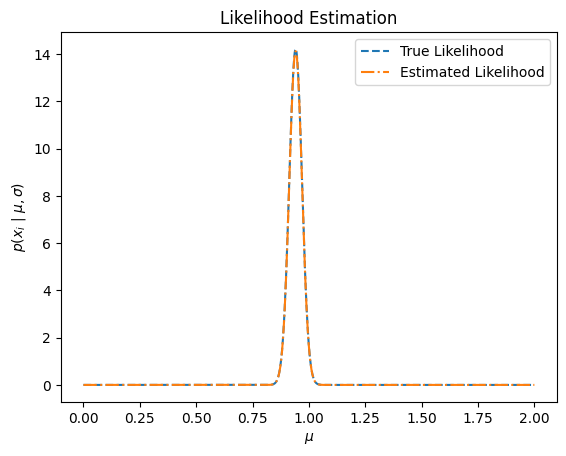

In [342]:
gauss=norm.pdf(x,mean,sigma_MLE)  

plt.plot(x, g/1040, ls='--', label='True Likelihood')
plt.plot(x, gauss, ls='-.', label='Estimated Likelihood')

plt.xlabel(r'$\mu$')
plt.ylabel(r'$p(x_i \ | \ \mu, \sigma)$')
plt.legend(loc='best')
plt.title("Likelihood Estimation");

They are the same! :)

# PART 3

## Heteroschedastic

### Generating Gaussian Data

In [8]:
mu=1
sigma=0.2
N=50
std=0.05
np.random.seed(3)
sigma=norm(sigma,std).rvs(N)

data=np.array([])
for i in range(len(sigma)):
    data_vecs=norm(mu,sigma[i]).rvs(1)
    data=np.append(data,data_vecs)

mean=np.average(data,weights=1/sigma**2)

### Gaussian Likelihood

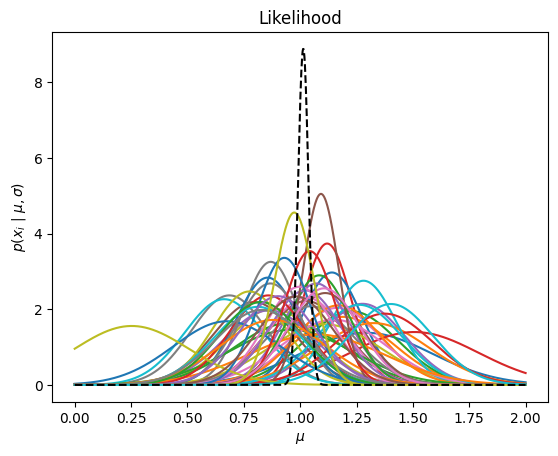

In [351]:
y = np.array([norm.pdf(x,loc,scale) for loc,scale in zip(data,sigma)])

g = np.prod(Ls,axis=0)
                                              
for i in range(len(y)):
    plt.plot(x, y[i], linestyle='-')
    
plt.plot(x, g/3500,ls='--',c='k')

plt.xlabel(r'$\mu$')
plt.ylabel(r'$p(x_i \ | \ \mu, \sigma)$')
plt.title("Likelihood");

In [358]:
idx=np.argmax(g)
maxL=x[idx]
print("Maximum Likelihood Estimator:",mean,"and value at which the Likelihood is maximized",maxL)
sigma_MLE=1/np.sqrt(np.sum(sigma**(-2)))

Maximum Likelihood Estimator: 1.013868169560046 and value at which the Likelihood is maximized 1.013013013013013


### Fisher Matrix

In [370]:
logg=np.log(g[g>0])
g2=np.diff(logg,2)
g3=-g2/(x[1]-[0])**2
g2=1/np.sqrt(g3[g3>0])[idx]
print("Fisher matrix error:", g2, "and rror on the Maximum Likelihood Estimator:",sigma_MLE)

Fisher matrix error: 0.023019295027103343 and rror on the Maximum Likelihood Estimator: 0.023019295027177786


### Likelihood check

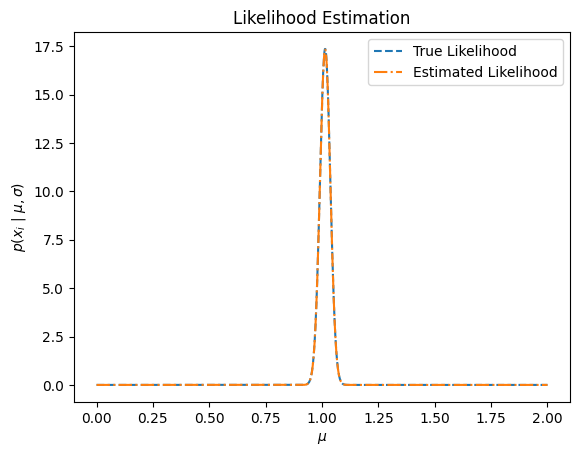

In [368]:
gauss=norm.pdf(x,mean,sigma_MLE)  

plt.plot(x, g/1790, ls='--', label='True Likelihood')
plt.plot(x, gauss, ls='-.', label='Estimated Likelihood')

plt.xlabel(r'$\mu$')
plt.ylabel(r'$p(x_i \ | \ \mu, \sigma)$')
plt.legend(loc='best')
plt.title("Likelihood Estimation");